## Dataset WINE

### Imports

In [73]:
#!pip install openpyxl
import os
import sys
import copy 

from typing import Any, Callable, Dict, Iterable, List, Tuple
from collections import Counter

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Add the parent directory to sys.path to be able to import own packages from outside the notebooks directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# some helper functions (see src directory for details)
from src.utils import *
from src.evaluation import *

# SKLEARN
from sklearn.base import BaseEstimator # Base class for all estimators in scikit-learn.
from sklearn.model_selection import train_test_split, ShuffleSplit, GridSearchCV, ShuffleSplit, StratifiedKFold
from sklearn.feature_selection import SelectKBest, SelectFromModel, RFECV, chi2, mutual_info_classif

from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


## Data Exploration

In [4]:
# Load the data and catch a quick glimpse.
curr_dir = os.getcwd()
data_path = os.path.join(curr_dir, '..', 'data', 'wine_data/wine_data.xlsx')

df_wine = pd.read_excel(data_path)

df_wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [5]:
df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [7]:
df_wine.isna().sum(), display(df_wine) # perfect, no missing values


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


(fixed acidity           0
 volatile acidity        0
 citric acid             0
 residual sugar          0
 chlorides               0
 free sulfur dioxide     0
 total sulfur dioxide    0
 density                 0
 pH                      0
 sulphates               0
 alcohol                 0
 quality                 0
 color                   0
 dtype: int64,
 None)

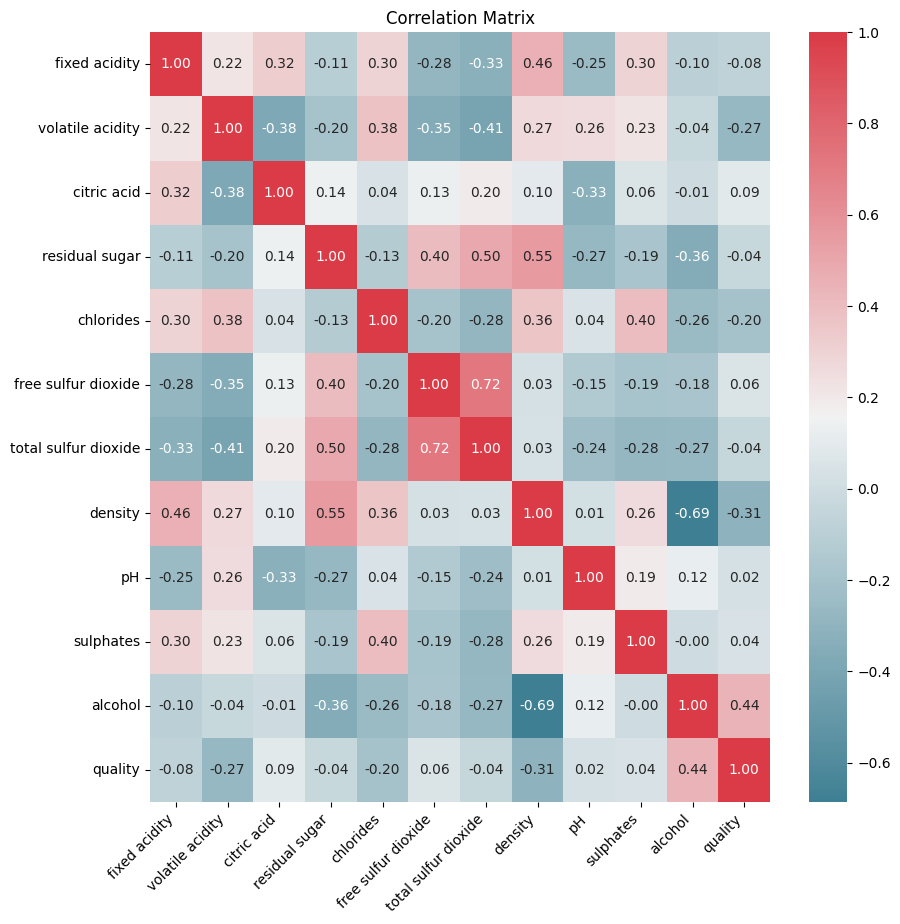

<Figure size 640x480 with 0 Axes>

In [ ]:
create_correlation_matrix(df_wine.drop("color", axis=1))

# correlation does not seem to be an issue. There are some fairly highly related ones, but from what I understand this might not be an issue.
# Maybe to keep an eye on the two types of sulfur dioxide, but there might be some value in keeping them both as there must be reason why both
# have been measured.

Scatter matrix shape: (12, 12)


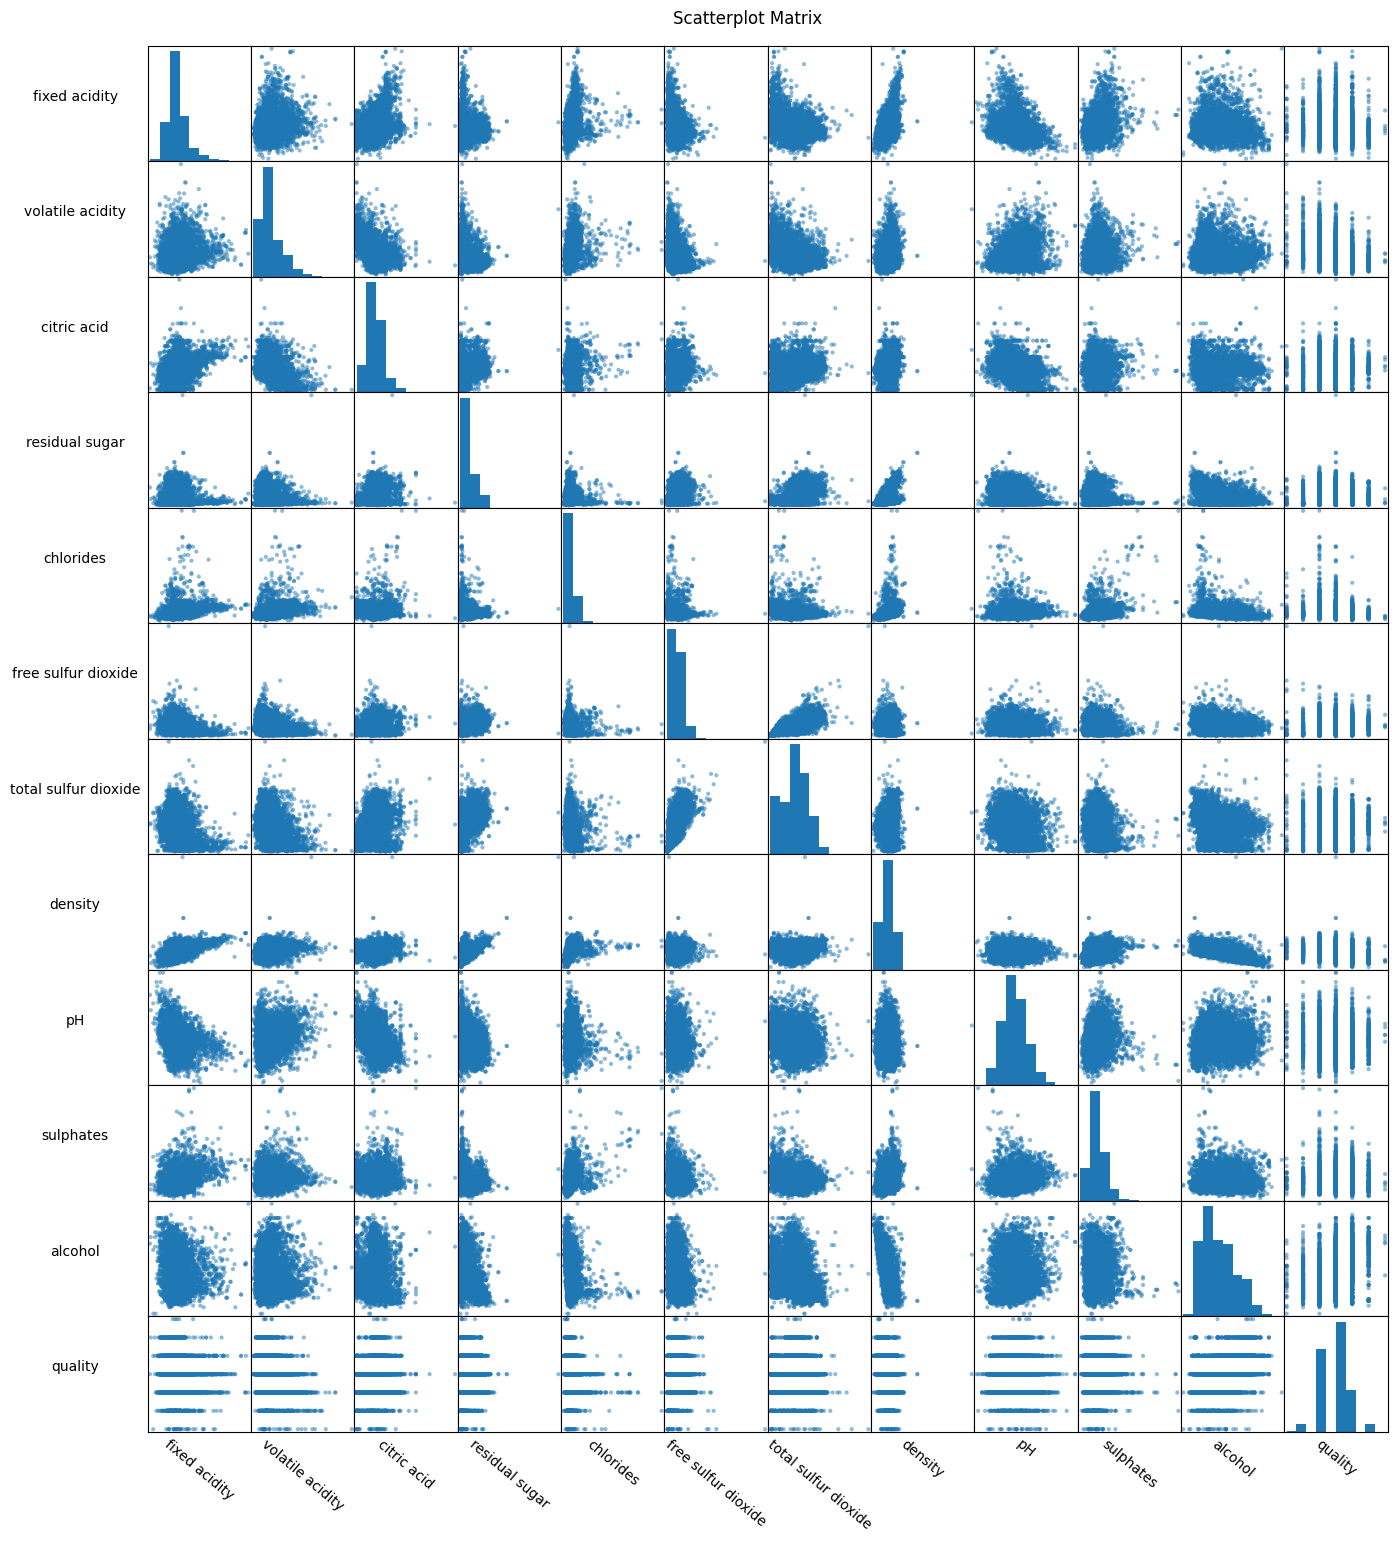

<Figure size 640x480 with 0 Axes>

In [ ]:
create_scatterplot_matrix(df_wine)

# here one can see very well that quality is of integer values. Overall we ofc see a similar picture as in the correlation amtrix before.
# For e.g. density we can see that there must be some tailing but nothing to be concerned of as of now, we would say.

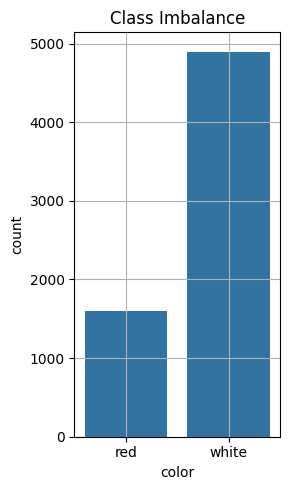

In [ ]:
fig, ax = plt.subplots(figsize=(3,5))
sns.countplot(data=df_wine, x="color")

ax.set_title("Class Imbalance")
ax.grid(True)

fig.tight_layout()
plt.show()

# there is quite the class imbalance here!

### Preparation for the classification part

<Axes: >

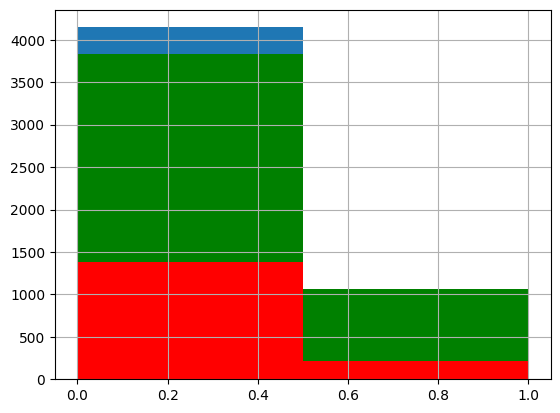

In [60]:
# We have to convert the quality parameter into some classes:
# 1-6 is bad, 7 & 8 & 9 is good

X = df_wine.drop('quality', axis=1)
y = df_wine['quality']

color_mapping = {"white": 0, "red": 1} # necessary, otherwise we cannot use this 
X["color"] = X["color"].map(color_mapping)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

bins = (1, 6, 9)
classes = [0, 1]

y = pd.cut(y, bins = bins, labels = classes)
y_train = pd.cut(y_train, bins = bins, labels = classes)
y_test = pd.cut(y_test, bins = bins, labels = classes)

y_train.hist(bins=2) # fairly imbalanced here as well

# just to see if this has something to do with the type
y_red = df_wine.loc[df_wine["color"]=="red"]['quality']
y_white = df_wine.loc[df_wine["color"]=="white"]['quality']

y_red = pd.cut(y_red, bins = bins, labels = classes)
y_white = pd.cut(y_white, bins = bins, labels = classes)

y_white.hist(bins=2, color = "green") 

y_red.hist(bins=2, color = "red")


## Machine Learning Part


### Exploring different preprocessing methods

In [ ]:
# two different preprocessing types, one with and one without scaling
variant_A = Pipeline([("scaler", StandardScaler())])
variant_B = Pipeline([])

preprocessing_variants = {"no_scale": variant_B, "scaling": variant_A}

# include crossvalidation as it is also possible to use other cross validation strategies by passing a cross validation iterator instead (https://scikit-learn.org/stable/modules/cross_validation.html)

# these three classifiers are choosen for all the different datasets for our team. Different vairables ofc.
classifiers = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', C=1.0), # C is the regularization parameter and 1 the default https://scikit-learn.org/stable/auto_examples/svm/plot_svm_scale_c.html#sphx-glr-auto-examples-svm-plot-svm-scale-c-py
    "DecisionTree": DecisionTreeClassifier(max_depth=None, random_state=21)
}

# Remark (copied from docu https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html#sphx-glr-auto-examples-svm-plot-svm-kernels-py): 
# The radial basis function (RBF) kernel, also known as the Gaussian kernel, is the default kernel for Support Vector Machines in scikit-learn. 
# It measures similarity between two data points in infinite dimensions and then approaches classification by majority vote. 

# ========== Doing the machine learning ==========

results = []
cv = ShuffleSplit(n_splits=10, test_size=0.3, random_state=21)
for prep_name, prep_pipeline in preprocessing_variants.items():
    for clf_name, clf in classifiers.items():
        # to capture all the results
        fold_metrics = []
        
        # iterate through al the folds
        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            if prep_name == "no_scale":
                pipe = Pipeline([
                ("classifier", clf)
            ])
            else:
                pipe = Pipeline([
                    ("preprocess", prep_pipeline),
                    ("classifier", clf)
                ])

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test) 
            # funfact as we were discussing potential leakage:
            # The pipeline only applies the preprocessing it learned from the training set 
            # e.g. imputation would be based on the training and the simply transpired through to the test. So no leakage!

            eval_dict = evaluate_run(
                name=f"{prep_name} + {clf_name} (fold {fold+1})",
                y_true=y_test,
                y_pred=y_pred,
                task_type="classification"
            )
            fold_metrics.append(eval_dict)

        # Aggregate across folds for stats 
        df_metrics = pd.DataFrame(fold_metrics)
        agg = df_metrics[['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall']].agg(['mean', 'std'])
        results.append({
            "Preprocessing": prep_name,
            "Classifier": clf_name,
            "accuracy_mean": agg.loc['mean', 'accuracy'],
            "accuracy_std": agg.loc['std', 'accuracy'],
            "b_accuracy_mean": agg.loc['mean', 'balanced_accuracy'],
            "b_accuracy_std": agg.loc['std', 'balanced_accuracy'],
            "f1_mean": agg.loc['mean', 'f1'],
            "f1_std": agg.loc['std', 'f1'],
            "precision_mean": agg.loc['mean', 'precision'],
            "recall_mean": agg.loc['mean', 'recall']
        })

results_df = pd.DataFrame(results)

# Remark we get the warning that "UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples."
# Not necessarily a problem, just means that some category is not predicted at all in some sample

/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classif

Okay we definetly need to scale! We get random guesses e.g. for SVM with a balanced accuracy of 0.5

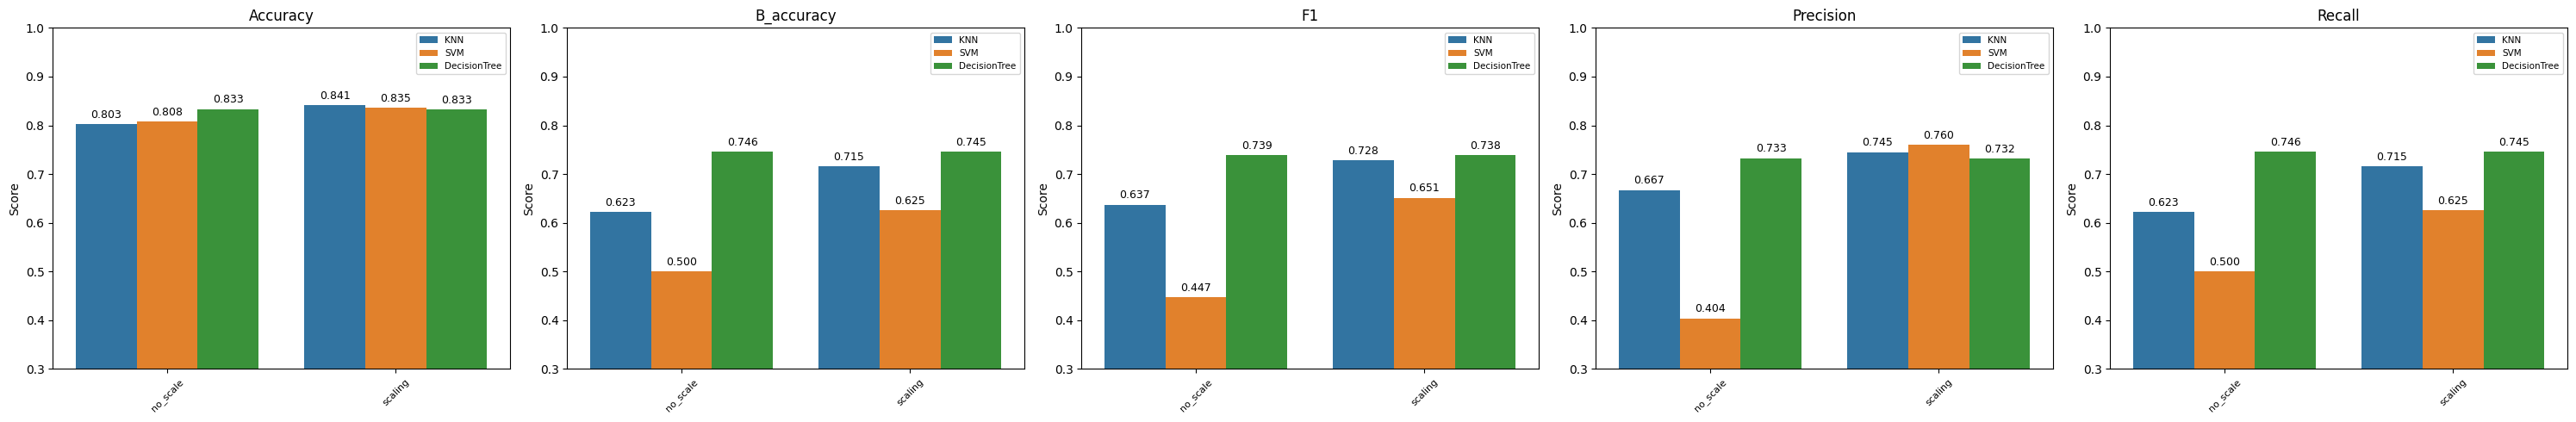


Cross-validation summary:


,Preprocessing,Classifier,accuracy_mean,accuracy_std,b_accuracy_mean,b_accuracy_std,f1_mean,f1_std,precision_mean,recall_mean
0,no_scale,KNN,0.803128,0.010297,0.622941,0.013648,0.637181,0.015148,0.667276,0.622941
1,no_scale,SVM,0.807795,0.005781,0.500000,0.000000,0.446835,0.001768,0.403897,0.500000
5,scaling,DecisionTree,0.832923,0.010327,0.745404,0.020512,0.738234,0.017401,0.732106,0.745404
2,no_scale,DecisionTree,0.833385,0.010303,0.745618,0.020082,0.738705,0.017005,0.732797,0.745618
4,scaling,SVM,0.835385,0.004719,0.625170,0.007638,0.651419,0.008852,0.760133,0.625170
3,scaling,KNN,0.841231,0.007265,0.715465,0.013655,0.728147,0.012663,0.745056,0.715465


In [70]:
metrics = ["accuracy_mean", "b_accuracy_mean", "f1_mean", "precision_mean", "recall_mean"]

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
axes = axes.flatten() # turn into a 1D list for indexing 

# plot one metric in one of the axes
for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=results_df,
        x="Preprocessing",
        y=metric,
        hue="Classifier", 
        ax=ax
    )

    # add the numbers above the bars
    for container in ax.containers: # Each container holds the bars for one classifier (hue)
        ax.bar_label(
            container,
            fmt="%.3f",          
            label_type="edge",
            padding=3,
            fontsize=9
        )
    
    ax.set_title(metric.capitalize().replace("_mean", ""))
    ax.set_ylim(0.30, 1.0)
    ax.set_xlabel("")
    ax.set_ylabel("Score")        
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.legend(fontsize=7.5) 


plt.tight_layout()
plt.show()

print("\nCross-validation summary:")
results_df.sort_values(by=["accuracy_mean"])


### Feature Selection Testing

Funfact: Due to scaling we introduced negative values in X which is not compatible with SelectKBest with chi2 as this assumes frequencies/counts! 

Hence we took mutual_info_classif instead of chi2. This is coming from information theory and basically gives an information how much of the target can be explained by a feature in X.

In [74]:
# Wikipedia Info:
# In probability theory and information theory, the mutual information (MI) of two random variables is a measure of the mutual dependence between the two variables. 
# More specifically, it quantifies the "amount of information" (in units such as shannons (bits), nats or hartleys obtained about one random variable by observing 
# the other random variable. The concept of mutual information is intimately linked to that of entropy o.  a random variable, a fundamental notion in information theory
# that quantifies the expected "amount of information" held in a random variable.

selection_variants = {
    "None": None,
    "SelectKBest_mi_k": SelectKBest(mutual_info_classif, k=5),
    "SelectFromModel_L1LogReg": SelectFromModel(
        LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=5000),
        threshold='median'
    ),
    "SelectFromModel_RF": SelectFromModel(
        RandomForestClassifier(n_estimators=200, random_state=21), # n_estimator = The number of trees in the forest.
        threshold='median'
    ),
    "RFECV_LogReg": RFECV(
        estimator=LogisticRegression(max_iter=5000),
        step=1, cv=3, scoring='f1', min_features_to_select=5
    )
}


classifiers = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', C=1.0), # gamma='scale'), >> Exclude here to compare results from preprocessing including, excluding StandardScaler!
    "DecisionTree": DecisionTreeClassifier(max_depth=None, random_state=21)
}

# Remark (copied from docu https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html#sphx-glr-auto-examples-svm-plot-svm-kernels-py): 
# The radial basis function (RBF) kernel, also known as the Gaussian kernel, is the default kernel for Support Vector Machines in scikit-learn. 
# It measures similarity between two data points in infinite dimensions and then approaches classification by majority vote. 

results = []
cv = ShuffleSplit(n_splits=10, test_size=0.3, random_state=21)
for sel_name, sel in selection_variants.items():
    for clf_name, clf in classifiers.items():
        # to capture all the results
        fold_metrics = []
        
        # iterate through al the folds as before
        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            pipe = Pipeline([
                ("preprocess", StandardScaler()),
                ("f_selection", sel),
                ("classifier", clf)
            ])

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test) 
            # >> funfact as we were discussing potential leakage:
            # The pipeline obviously only applies the preprocessing it learned from the training set 
            # e.g. imputation would be based on the training and the simply transpired through to the test. So no leakage!

            eval_dict = evaluate_run(
                name=f"{sel_name} + {clf_name} (fold {fold+1})",
                y_true=y_test,
                y_pred=y_pred,
                task_type="classification"
            )
            fold_metrics.append(eval_dict)

        # Aggregate across folds for stats 
        df_metrics = pd.DataFrame(fold_metrics)
        agg = df_metrics[['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall']].agg(['mean', 'std'])
        results.append({
            "Feature_Selection": sel_name,
            "Classifier": clf_name,
            "accuracy_mean": agg.loc['mean', 'accuracy'],
            "accuracy_std": agg.loc['std', 'accuracy'],
            "b_accuracy_mean": agg.loc['mean', 'balanced_accuracy'],
            "b_accuracy_std": agg.loc['std', 'balanced_accuracy'],
            "f1_mean": agg.loc['mean', 'f1'],
            "f1_std": agg.loc['std', 'f1'],
            "precision_mean": agg.loc['mean', 'precision'],
            "recall_mean": agg.loc['mean', 'recall']
        })

results_df = pd.DataFrame(results)


In [76]:
results_df

,Feature_Selection,Classifier,accuracy_mean,accuracy_std,b_accuracy_mean,b_accuracy_std,f1_mean,f1_std,precision_mean,recall_mean
0,None,KNN,0.841231,0.007265,0.715465,0.013655,0.728147,0.012663,0.745056,0.715465
1,None,SVM,0.835385,0.004719,0.625170,0.007638,0.651419,0.008852,0.760133,0.625170
2,None,DecisionTree,0.832923,0.010327,0.745404,0.020512,0.738234,0.017401,0.732106,0.745404
3,SelectKBest_mi_k,KNN,0.815128,0.010125,0.676001,0.011808,0.685411,0.013222,0.698114,0.676001
4,SelectKBest_mi_k,SVM,0.820154,0.005995,0.575251,0.009863,0.585751,0.014035,0.722263,0.575251
5,SelectKBest_mi_k,DecisionTree,0.819846,0.008378,0.726407,0.011935,0.718983,0.011635,0.712956,0.726407
6,SelectFromModel_L1LogReg,KNN,0.825538,0.010199,0.682755,0.008850,0.696431,0.010268,0.716487,0.682755
7,SelectFromModel_L1LogReg,SVM,0.824564,0.006962,0.591443,0.007191,0.608500,0.010347,0.734275,0.591443
8,SelectFromModel_L1LogReg,DecisionTree,0.827538,0.014300,0.733061,0.018653,0.728115,0.019416,0.724096,0.733061
9,SelectFromModel_RF,KNN,0.822718,0.008381,0.681937,0.014568,0.693919,0.014724,0.711003,0.681937


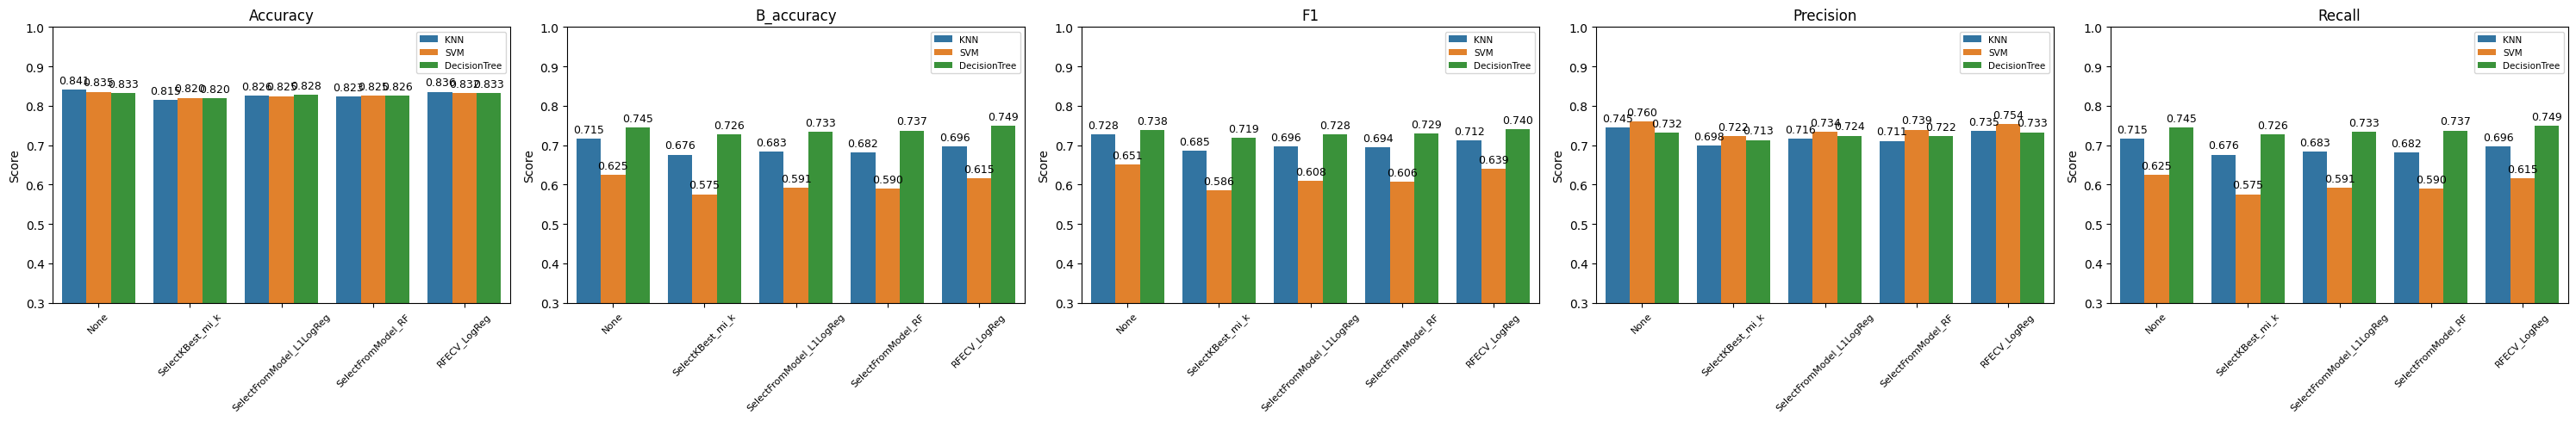


Cross-validation summary:


,Feature_Selection,Classifier,accuracy_mean,accuracy_std,b_accuracy_mean,b_accuracy_std,f1_mean,f1_std,precision_mean,recall_mean
3,SelectKBest_mi_k,KNN,0.815128,0.010125,0.676001,0.011808,0.685411,0.013222,0.698114,0.676001
5,SelectKBest_mi_k,DecisionTree,0.819846,0.008378,0.726407,0.011935,0.718983,0.011635,0.712956,0.726407
4,SelectKBest_mi_k,SVM,0.820154,0.005995,0.575251,0.009863,0.585751,0.014035,0.722263,0.575251
9,SelectFromModel_RF,KNN,0.822718,0.008381,0.681937,0.014568,0.693919,0.014724,0.711003,0.681937
7,SelectFromModel_L1LogReg,SVM,0.824564,0.006962,0.591443,0.007191,0.608500,0.010347,0.734275,0.591443
10,SelectFromModel_RF,SVM,0.825179,0.005723,0.590054,0.012262,0.606358,0.017298,0.739392,0.590054
6,SelectFromModel_L1LogReg,KNN,0.825538,0.010199,0.682755,0.008850,0.696431,0.010268,0.716487,0.682755
11,SelectFromModel_RF,DecisionTree,0.826051,0.006177,0.737258,0.012924,0.729002,0.010784,0.722451,0.737258
8,SelectFromModel_L1LogReg,DecisionTree,0.827538,0.014300,0.733061,0.018653,0.728115,0.019416,0.724096,0.733061
13,RFECV_LogReg,SVM,0.832308,0.005443,0.615088,0.008834,0.639166,0.011193,0.753508,0.615088


In [77]:
metrics = ["accuracy_mean", "b_accuracy_mean", "f1_mean", "precision_mean", "recall_mean"]

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
axes = axes.flatten() # turn into a 1D list for indexing 

# plot one metric in one of the axes
for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=results_df,
        x="Feature_Selection",
        y=metric,
        hue="Classifier", 
        ax=ax
    )

    # add the numbers above the bars
    for container in ax.containers: # Each container holds the bars for one classifier (hue)
        ax.bar_label(
            container,
            fmt="%.3f",          
            label_type="edge",
            padding=3,
            fontsize=9
        )
    
    ax.set_title(metric.capitalize().replace("_mean", ""))
    ax.set_ylim(0.30, 1.0)
    ax.set_xlabel("")
    ax.set_ylabel("Score")        
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.legend(fontsize=7.5) 


plt.tight_layout()
plt.show()

print("\nCross-validation summary:")
results_df.sort_values(by=["accuracy_mean"])


### Combining it all

In [87]:
def nested_selection_search(
    X: pd.DataFrame,
    y: pd.Series,
    preprocessor: BaseEstimator,
    selector_grid_dict: Dict[str, Tuple[Callable[..., BaseEstimator], Dict[str, Iterable[Any]]]],
    classifier_grid_dict: Dict[str, Tuple[Callable[..., BaseEstimator], Dict[str, Iterable[Any]]]],
    outer_cv: ShuffleSplit | None = None,
    inner_cv: StratifiedKFold | None = None,
    scoring: str = 'balanced_accuracy', # balanced_accuracy mainly because its a balanced score, not much more thought behind that
    random_state: int = 21
) -> Tuple[pd.DataFrame, pd.DataFrame, List[GridSearchCV]]:
    """
    Nested CV search over selector + classifier hyperparameters.

    Parameters
    ----------
    X
        Feature DataFrame
    y
        Target series (must have already encoded labels!)
    preprocessor
        Preprocessor
    selector_grid_dict
        The str links to (constructor_callable, param_grid)
        - constructor_callable: callable that returns an unfitted selector when called with no args
        - param_grid: dict mapping of selector names to potential values
    classifier_grid_dict
        The str links to (constructor_callable, param_grid)
        - constructor_callable: callable that returns an unfitted classifier when called with no args
        - param_grid: dict mapping of classifier variables to potential values
    outer_cv
        Outer CV as done in the beginning
    inner_cv
        Inner CV used by GridSearchCV. Is only used to tune hyperparameters on the respective outer training fold only (per loop iteration).
    scoring
        Metric used by GridSearchCV ('f1' here as default).
    random_state
        Some seed

    Returns
    -------
    results_df
        DataFrame with all used variables for the model including various metrics as before
    feature_freq_df
        Aggregated frequency table across all selections
    grid_search_objects
        List of GridSearchCV objects created for Debugging/Analysis
    """

    # defaults
    if outer_cv is None:
        outer_cv = ShuffleSplit(n_splits=10, test_size=0.3, random_state=random_state)
    if inner_cv is None:
        inner_cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=random_state)

    results: List[Dict[str, Any]] = []
    grid_objects: List[GridSearchCV] = []

    # Initiate the combo of selectors + classifiers for thr GridSearchCV
    combo_list = []
    for sel_label, (sel_ctor, sel_param_grid) in selector_grid_dict.items():
        for clf_label, (clf_ctor, clf_param_grid) in classifier_grid_dict.items():
            # prefix param names for the pipeline (the steps are called "selector", "classifier"; hence we need to add the prefixes)
            param_grid: Dict[str, Iterable[Any]] = {}

            # create the dicts if not already existing
            sel_param_grid = sel_param_grid or {} 
            clf_param_grid = clf_param_grid or {}

            for k, v in sel_param_grid.items():
                param_grid[f"selector__{k}"] = v
            for k, v in clf_param_grid.items():
                param_grid[f"classifier__{k}"] = v

            combo_list.append({
                "sel_label": sel_label,
                "clf_label": clf_label,
                "sel_ctor": sel_ctor,
                "clf_ctor": clf_ctor,
                "param_grid": param_grid
            })

    # iterate through the combos now
    for combo in combo_list:
        sel_label = combo["sel_label"]
        clf_label = combo["clf_label"]
        param_grid = combo["param_grid"]

        for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # instantiate "fresh" selector and classifier for each fold 
            selector = combo["sel_ctor"]() # >> is callable as you defined it that way to get it "fresh" each time!
            classifier = combo["clf_ctor"]()

            pipe = Pipeline([
                ("preprocess", preprocessor),
                ("selector", selector),
                ("classifier", classifier)
            ])
            
            # gridwork whoop
            grid = GridSearchCV(
                estimator=pipe,
                param_grid=param_grid,
                cv=inner_cv,
                scoring=scoring,
                refit=True,
                return_train_score=False
            )
            grid.fit(X_train, y_train)
            best_pipe = grid.best_estimator_
            best_params = grid.best_params_
            grid_objects.append(grid)

            # Evaluate on outer(!) test fold
            y_pred = best_pipe.predict(X_test)

            eval_dict = evaluate_run(
                name=f"{sel_label} + {clf_label} (fold {outer_fold+1})",
                y_true=y_test,
                y_pred=y_pred,
                task_type="classification"
            )

            ### Now get all the data for evaluation

            # get transformed feature names
            preproc = best_pipe.named_steps["preprocess"]
            transformed_names = preproc.get_feature_names_out(X.columns)
            
            # get the selected features 
            sel_step = best_pipe.named_steps.get("selector", None)
            selected_features: List[str]
            if sel_step is None:
                selected_features = list(transformed_names)
            else:
                # normally you get a mask from the selector with get_support() method (returns boolean array telling you which columns to keep/not to keep)
                if hasattr(sel_step, "get_support"):
                    mask = sel_step.get_support()
                    selected_features = list(np.array(transformed_names)[mask])
                elif hasattr(sel_step, "estimator_") and hasattr(sel_step.estimator_, "coef_"):
                    coef = sel_step.estimator_.coef_
                    mask = np.any(np.abs(coef) > 0, axis=0)
                    selected_features = list(np.array(transformed_names)[mask])
                # RFECV and have it in support_ apparently as well
                elif hasattr(sel_step, "support_"):
                    mask = sel_step.support_
                    selected_features = list(np.array(transformed_names)[mask])
                else:
                    selected_features = []

            # record results
            eval_dict.update({
                "outer_fold": outer_fold,
                "sel_label": sel_label,
                "sel_step": sel_step,
                "clf_label": clf_label,
                "best_params": best_params,
                "n_selected": len(selected_features),
                "selected_features": selected_features
            })
            results.append(eval_dict)

    results_df = pd.DataFrame(results)
    
    # Generate one dataframe with all the relevant information of the selected features
    
    # First, unpack all the features into a single flat list
    all_selected = [feat for feats in results_df.get("selected_features", []) for feat in feats]
    # get the frequencies (appearances) of each feature
    freq = Counter(all_selected)
    total_runs = len(results_df)

    freq_items = [(feat, cnt, cnt / total_runs) for feat, cnt in freq.most_common()] # if we do not pass n to most_common we get a sorted dict basically (See Go Defintion)
    feature_freq_df = pd.DataFrame(freq_items, columns=["feature", "selected_count", "selected_fraction"])

    return results_df, feature_freq_df, grid_objects


In [ ]:
# As the selectors consist of estimators themselves, we need to pass the variables (like n_estimator) with this estimator prefix, as the thing inside the SelectFromModel is an estimator.
# IN the function nested_selection_search() we then also append the correct prefix selector__ liek we do for the classifier with __classifier
selector_grid_dict = {
    "SelectKBest_mi": (lambda: SelectKBest(mutual_info_classif, k=5), {"k":[5,10,20]}),
    # l1 as we want the coefficients to become 0, C = Inverse of regularization strength; must be a positive float. Like in support vector machines, smaller values specify stronger regularization. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
    "L1_LogReg_SFM": (lambda: SelectFromModel(LogisticRegression(penalty='l1', solver='saga', max_iter=5000)), {"threshold":['median'], "estimator__C":[0.1,1.0]}), 
    "RF_SFM": (lambda: SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=0)), {"threshold":['median'], "estimator__n_estimators":[100,200]}) # n...The number of trees in the forest.
}

classifier_grid_dict = {
    "SVM_RBF": (lambda: SVC(kernel='rbf'), {"C":[0.1,1.0]}),
    "KNN": (lambda: KNeighborsClassifier(), {"n_neighbors":[3,5,7]}),
    "DecisionTree": (lambda: DecisionTreeClassifier(random_state=21), {"max_depth":[None,3,5,7], "criterion":["gini", "entropy"] })
}

# Remark (copied from docu https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html#sphx-glr-auto-examples-svm-plot-svm-kernels-py): 
# The radial basis function (RBF) kernel, also known as the Gaussian kernel, is the default kernel for Support Vector Machines in scikit-learn. 
# It measures similarity between two data points in infinite dimensions and then approaches classification by majority vote. 

# For reference - runtime is usually around 7.5 min on an M1 Macbook Air
results_df, feature_freq_df, grid_objs = nested_selection_search(
    X=X,
    y=y,
    preprocessor=StandardScaler(), # remark: chosen because it performed best before.
    selector_grid_dict=selector_grid_dict,
    classifier_grid_dict=classifier_grid_dict,
    outer_cv=ShuffleSplit(n_splits=10, test_size=0.3, random_state=21),
    inner_cv=StratifiedKFold(n_splits=3),
    scoring='balanced_accuracy',
    random_state=21
)

/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=12. All the features will be returned.
  warnings.warn(
/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=12. All the features will be returned.
  warnings.warn(
/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=12. All the features will be returned.
  warnings.warn(
/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/.venv/lib/py

In [90]:
feature_freq_df

,feature,selected_count,selected_fraction
0,volatile acidity,30,1.000000
1,alcohol,30,1.000000
2,residual sugar,28,0.933333
3,density,28,0.933333
4,chlorides,23,0.766667
5,sulphates,19,0.633333
6,fixed acidity,17,0.566667
7,total sulfur dioxide,16,0.533333
8,pH,16,0.533333
9,citric acid,10,0.333333


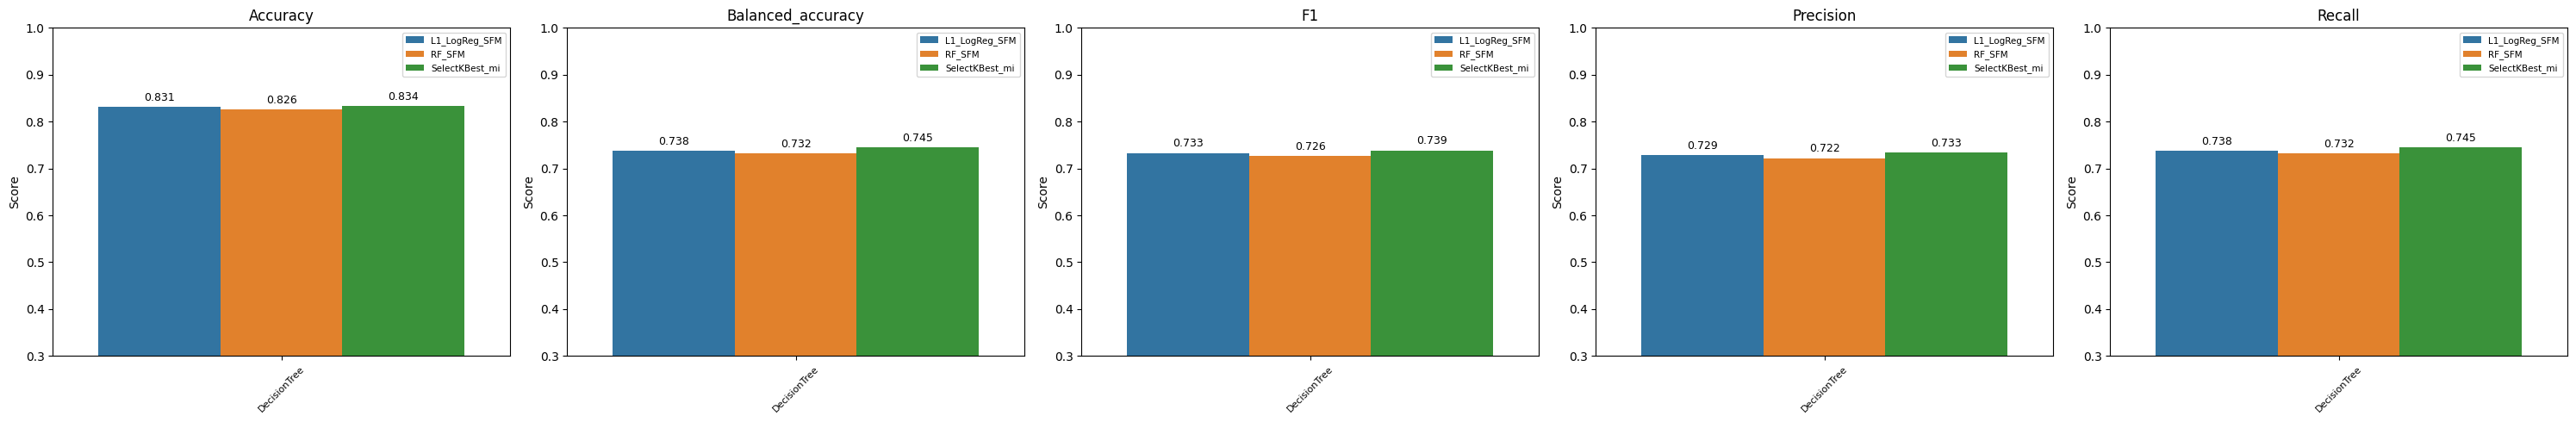

,sel_label,clf_label,accuracy_mean,balanced_accuracy_mean,f1_mean,precision_mean,recall_mean,n_selected_mean,accuracy_std,balanced_accuracy_std,f1_std,precision_std,recall_std,n_selected_std
2,SelectKBest_mi,DecisionTree,0.833744,0.744737,0.738649,0.733359,0.744737,11.4,0.009099,0.015001,0.014831,0.015200,0.015001,0.966092
0,L1_LogReg_SFM,DecisionTree,0.830974,0.738011,0.733098,0.728771,0.738011,6.0,0.009313,0.016998,0.015469,0.014679,0.016998,0.000000
1,RF_SFM,DecisionTree,0.826359,0.731779,0.726460,0.722025,0.731779,6.0,0.007634,0.013059,0.013686,0.015156,0.013059,0.000000


In [91]:
# aggregated metrics per combo
agg = results_df.groupby(["sel_label","clf_label"]).agg({
    "accuracy":"mean",
    "balanced_accuracy":"mean",
    "f1":"mean",
    "precision":"mean",
    "recall":"mean",
    "n_selected":"mean"
}).rename(columns=lambda c: c + "_mean")
# also keep std (esp. interesting for the n_selected!)
agg_std = results_df.groupby(["sel_label","clf_label"]).agg({
    "accuracy":"std","balanced_accuracy":"std","f1":"std","precision":"std","recall":"std","n_selected":"std"
}).rename(columns=lambda c: c + "_std")

summary_table = pd.concat([agg, agg_std], axis=1).reset_index()

# metrics to plot as before
metrics = ["accuracy_mean", "balanced_accuracy_mean", "f1_mean", "precision_mean", "recall_mean"]

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
axes = axes.flatten() # turn into a 1D list for indexing

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=agg,
        x="clf_label",
        y=metric,
        hue="sel_label",
        ax=ax
    )

    # add the numbers above the bars
    for container in ax.containers: # Each container holds the bars for one classifier (hue)
        ax.bar_label(
            container,
            fmt="%.3f",          
            label_type="edge",
            padding=3,
            fontsize=9
        )
    
    ax.set_title(metric.capitalize().replace("_mean", ""))
    ax.set_ylim(0.3, 1.0)
    ax.set_xlabel("")
    ax.set_ylabel("Score")        
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.legend(fontsize=7.5) 


plt.tight_layout()
plt.show()

display(summary_table.sort_values(by="f1_mean", ascending=False).head(20))


In [92]:
agg

,,accuracy_mean,balanced_accuracy_mean,f1_mean,precision_mean,recall_mean,n_selected_mean
sel_label,clf_label,,,,,,
L1_LogReg_SFM,DecisionTree,0.830974,0.738011,0.733098,0.728771,0.738011,6.0
RF_SFM,DecisionTree,0.826359,0.731779,0.726460,0.722025,0.731779,6.0
SelectKBest_mi,DecisionTree,0.833744,0.744737,0.738649,0.733359,0.744737,11.4


In [101]:
print(results_df.sort_values(by="balanced_accuracy", ascending=False).iloc[0,:].best_params)
print(results_df.sort_values(by="balanced_accuracy", ascending=False).iloc[0,:])

{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'selector__k': 20}
id                                7a72082a-5c90-45af-9479-1e1e3bcc67b5
name                           SelectKBest_mi + DecisionTree (fold 10)
task_type                                               classification
accuracy                                                      0.847692
balanced_accuracy                                             0.765625
f1                                                            0.759463
precision                                                       0.7539
recall                                                        0.765625
conf_matr                                    [[1417, 160], [137, 236]]
outer_fold                                                           9
sel_label                                               SelectKBest_mi
sel_step             SelectKBest(k=20, score_func=<function mutual_...
clf_label                                                 Dec

**Remark** It proved that entropy instead of gini as the impurity measure is more favorable
Entropy – measure of uncertainty > the higher the worse for prediction

Generally some sources (e.g. https://www.geeksforgeeks.org/machine-learning/gini-impurity-and-entropy-in-decision-tree-ml/) say that gini is more sensitive to class imbalances, which could be the reason here for why entropy is perfoming slightly better!